In [1]:
from pathlib import Path
import os
import sys
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "oceanbench").exists() and (path / "assets").exists()),
    Path.cwd(),
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

stale_oceanbench_modules = [
    module_name
    for module_name in list(sys.modules)
    if module_name == "oceanbench" or module_name.startswith("oceanbench.")
]
for module_name in sorted(stale_oceanbench_modules, reverse=True):
    sys.modules.pop(module_name, None)

CACHE_DIR = Path("/tmp/oceanbench-demo-cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
MPL_CACHE_DIR = CACHE_DIR / "matplotlib"
MPL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["XDG_CACHE_HOME"] = str(CACHE_DIR)
os.environ["MPLCONFIGDIR"] = str(MPL_CACHE_DIR)


In [2]:
import oceanbench

oceanbench.__version__

'0.0.3'

### Open challenger dataset

Local GLONET demo sample cached under `demo_data/glonet_sample/`.

In [3]:
# Open local GLONET demo sample with xarray for PSD diagnostics
import xarray
from oceanbench.demo import glonet

glonet.ensure_local_demo_data_exists()
glonet.configure_local_reference_paths()

challenger_dataset: xarray.Dataset = glonet.load_local_challenger_dataset()
challenger_dataset


<xarray.Dataset> Size: 206MB
Dimensions:                          (depth: 21, first_day_datetime: 1,
                                      lead_day_index: 10, latitude: 168,
                                      longitude: 360)
Coordinates:
  * depth                            (depth) float32 84B 0.494 ... 5.275e+03
  * first_day_datetime               (first_day_datetime) datetime64[ns] 8B 2...
  * latitude                         (latitude) float64 1kB -77.5 -76.5 ... 89.5
  * lead_day_index                   (lead_day_index) int64 80B 0 1 2 ... 7 8 9
  * longitude                        (longitude) float64 3kB -179.5 ... 179.5
Data variables:
    eastward_sea_water_velocity      (first_day_datetime, lead_day_index, depth, latitude, longitude) float32 51MB dask.array<chunksize=(1, 1, 1, 168, 360), meta=np.ndarray>
    northward_sea_water_velocity     (first_day_datetime, lead_day_index, depth, latitude, longitude) float32 51MB dask.array<chunksize=(1, 1, 1, 168, 360), meta=np.ndarray>
    sea_surface_height_above_geoid   (first_day_datetime, lead_day_index, latitude, longitude) float32 2MB dask.array<chunksize=(1, 1, 168, 360), meta=np.ndarray>
    sea_water_potential_temperature  (first_day_datetime, lead_day_index, depth, latitude, longitude) float32 51MB dask.array<chunksize=(1, 1, 1, 168, 360), meta=np.ndarray>
    sea_water_salinity               (first_day_datetime, lead_day_index, depth, latitude, longitude) float32 51MB dask.array<chunksize=(1, 1, 1, 168, 360), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

In [4]:
from oceanbench.core.dataset_utils import Variable
from oceanbench.core.references.glorys import glorys_reanalysis_dataset

glorys_dataset = glorys_reanalysis_dataset(challenger_dataset)


### GLONET vs GLORYS PSD diagnostics

#### SSH zonal PSD

In [5]:
challenger_ssh_psd, glorys_ssh_psd = oceanbench.psd.zonal_longitude_psd_pair(
    challenger_dataset,
    glorys_dataset,
    Variable.SEA_SURFACE_HEIGHT_ABOVE_GEOID,
)
challenger_ssh_psd

<xarray.DataArray 'sea_surface_height_above_geoid' (lead_day_index: 10,
                                                    freq_lon: 179)> Size: 14kB
array([[2.98741235e+05, 2.54403532e+05, 1.08515595e+05, ...,
        2.56612108e+02, 2.06109914e+02, 1.93734255e+02],
       [2.96204390e+05, 2.54822164e+05, 1.08345254e+05, ...,
        2.51436589e+02, 2.02988919e+02, 1.88555756e+02],
       [3.02536838e+05, 2.60240972e+05, 1.08896253e+05, ...,
        2.63877705e+02, 2.10486112e+02, 1.92507821e+02],
       ...,
       [3.00738503e+05, 2.57883421e+05, 1.09953481e+05, ...,
        2.62598677e+02, 2.13639500e+02, 1.89746285e+02],
       [2.99252035e+05, 2.58057178e+05, 1.09097903e+05, ...,
        2.66265335e+02, 2.16275624e+02, 1.93714912e+02],
       [2.95695471e+05, 2.57297189e+05, 1.08103330e+05, ...,
        2.60597995e+02, 2.13089750e+02, 1.87977558e+02]])
Coordinates:
    first_day_datetime  datetime64[ns] 8B 2024-01-03
  * lead_day_index      (lead_day_index) float32 40B 0.0 1.0 2.0 ... 7.0 8.0 9.0
  * freq_lon            (freq_lon) float64 1kB 3.703e-08 7.406e-08 ... 6.628e-06

#### Wavelength bands used for zonal PSD scores

In [6]:
zonal_wavelength_bands_km = oceanbench.psd.default_zonal_wavelength_bands_km(challenger_ssh_psd)
zonal_wavelength_bands_km

{'Large scale': (2000.0, 27006.171874443848),
 'Regional scale': (500.0, 2000.0),
 'Near-grid scale': (150.87246857231202, 500.0)}

#### SSH zonal PSD scores for all lead days

In [7]:
import pandas

ssh_psd_scores = pandas.concat(
    {
        "GLONET": oceanbench.psd.zonal_longitude_psd_metrics_from_spectrum(
            challenger_ssh_psd,
            wavelength_bands_km=zonal_wavelength_bands_km,
        ),
        "GLORYS": oceanbench.psd.zonal_longitude_psd_metrics_from_spectrum(
            glorys_ssh_psd,
            wavelength_bands_km=zonal_wavelength_bands_km,
        ),
    }
)
ssh_psd_scores

Lead day 1  \
GLONET Large scale band-integrated energy (2000-27006 km)    0.030402   
       Large scale band energy fraction (2000-27006 km)      0.781075   
       Regional scale band-integrated energy (500-2000...    0.005406   
       Regional scale band energy fraction (500-2000 km)     0.138892   
       Near-grid scale band-integrated energy (151-500...    0.002538   
       Near-grid scale band energy fraction (151-500 km)     0.065208   
       Near-grid scale noise index (Near-grid scale / ...    0.469490   
GLORYS Large scale band-integrated energy (2000-27006 km)    0.031733   
       Large scale band energy fraction (2000-27006 km)      0.786533   
       Regional scale band-integrated energy (500-2000...    0.005510   
       Regional scale band energy fraction (500-2000 km)     0.136560   
       Near-grid scale band-integrated energy (151-500...    0.002529   
       Near-grid scale band energy fraction (151-500 km)     0.062675   
       Near-grid scale noise index (Near-grid scale / ...    0.458953   

                                                           Lead day 2  \
GLONET Large scale band-integrated energy (2000-27006 km)    0.030314   
       Large scale band energy fraction (2000-27006 km)      0.781188   
       Regional scale band-integrated energy (500-2000...    0.005393   
       Regional scale band energy fraction (500-2000 km)     0.138983   
       Near-grid scale band-integrated energy (151-500...    0.002524   
       Near-grid scale band energy fraction (151-500 km)     0.065050   
       Near-grid scale noise index (Near-grid scale / ...    0.468044   
GLORYS Large scale band-integrated energy (2000-27006 km)    0.031762   
       Large scale band energy fraction (2000-27006 km)      0.784710   
       Regional scale band-integrated energy (500-2000...    0.005559   
       Regional scale band energy fraction (500-2000 km)     0.137348   
       Near-grid scale band-integrated energy (151-500...    0.002578   
       Near-grid scale band energy fraction (151-500 km)     0.063692   
       Near-grid scale noise index (Near-grid scale / ...    0.463731   

                                                           Lead day 3  \
GLONET Large scale band-integrated energy (2000-27006 km)    0.030872   
       Large scale band energy fraction (2000-27006 km)      0.780636   
       Regional scale band-integrated energy (500-2000...    0.005502   
       Regional scale band energy fraction (500-2000 km)     0.139137   
       Near-grid scale band-integrated energy (151-500...    0.002591   
       Near-grid scale band energy fraction (151-500 km)     0.065512   
       Near-grid scale noise index (Near-grid scale / ...    0.470847   
GLORYS Large scale band-integrated energy (2000-27006 km)    0.032072   
       Large scale band energy fraction (2000-27006 km)      0.785746   
       Regional scale band-integrated energy (500-2000...    0.005581   
       Regional scale band energy fraction (500-2000 km)     0.136732   
       Near-grid scale band-integrated energy (151-500...    0.002581   
       Near-grid scale band energy fraction (151-500 km)     0.063230   
       Near-grid scale noise index (Near-grid scale / ...    0.462441   

                                                           Lead day 4  \
GLONET Large scale band-integrated energy (2000-27006 km)    0.030777   
       Large scale band energy fraction (2000-27006 km)      0.780242   
       Regional scale band-integrated energy (500-2000...    0.005500   
       Regional scale band energy fraction (500-2000 km)     0.139425   
       Near-grid scale band-integrated energy (151-500...    0.002585   
       Near-grid scale band energy fraction (151-500 km)     0.065526   
       Near-grid scale noise index (Near-grid scale / ...    0.469970   
GLORYS Large scale band-integrated energy (2000-27006 km)    0.032141   
       Large scale band energy fraction (2000-27006 km)      0.786737   
       Regional scale band-integrated ene

#### SST zonal PSD

In [8]:
challenger_sst_psd, glorys_sst_psd = oceanbench.psd.zonal_longitude_psd_pair(
    challenger_dataset,
    glorys_dataset,
    Variable.SEA_WATER_POTENTIAL_TEMPERATURE,
)
challenger_sst_psd

<xarray.DataArray 'sea_water_potential_temperature' (lead_day_index: 10,
                                                     freq_lon: 179)> Size: 14kB
array([[1.00738733e+08, 1.04448062e+08, 1.04061947e+08, ...,
        2.54646202e+05, 2.50935213e+05, 2.13520393e+05],
       [1.00554552e+08, 1.04284036e+08, 1.04164861e+08, ...,
        2.52891019e+05, 2.49199562e+05, 2.13070147e+05],
       [1.00998732e+08, 1.04466327e+08, 1.04031631e+08, ...,
        2.56429320e+05, 2.53295259e+05, 2.17489957e+05],
       ...,
       [1.00481444e+08, 1.03561208e+08, 1.03968675e+08, ...,
        2.49960005e+05, 2.50342712e+05, 2.15934558e+05],
       [1.00191614e+08, 1.03667675e+08, 1.03602017e+08, ...,
        2.51840645e+05, 2.53211339e+05, 2.18522374e+05],
       [9.98241908e+07, 1.03181848e+08, 1.03464438e+08, ...,
        2.48349818e+05, 2.49103700e+05, 2.13847357e+05]])
Coordinates:
    depth               float32 4B 0.494
    first_day_datetime  datetime64[ns] 8B 2024-01-03
  * lead_day_index      (lead_day_index) float32 40B 0.0 1.0 2.0 ... 7.0 8.0 9.0
  * freq_lon            (freq_lon) float64 1kB 3.703e-08 7.406e-08 ... 6.628e-06

#### SST zonal PSD scores for all lead days

In [9]:
sst_psd_scores = pandas.concat(
    {
        "GLONET": oceanbench.psd.zonal_longitude_psd_metrics_from_spectrum(
            challenger_sst_psd,
            wavelength_bands_km=zonal_wavelength_bands_km,
        ),
        "GLORYS": oceanbench.psd.zonal_longitude_psd_metrics_from_spectrum(
            glorys_sst_psd,
            wavelength_bands_km=zonal_wavelength_bands_km,
        ),
    }
)
sst_psd_scores

Lead day 1  \
GLONET Large scale band-integrated energy (2000-27006 km)   24.875743   
       Large scale band energy fraction (2000-27006 km)      0.765736   
       Regional scale band-integrated energy (500-2000...    4.990472   
       Regional scale band energy fraction (500-2000 km)     0.153619   
       Near-grid scale band-integrated energy (151-500...    2.106488   
       Near-grid scale band energy fraction (151-500 km)     0.064843   
       Near-grid scale noise index (Near-grid scale / ...    0.422102   
GLORYS Large scale band-integrated energy (2000-27006 km)   25.360719   
       Large scale band energy fraction (2000-27006 km)      0.768555   
       Regional scale band-integrated energy (500-2000...    5.090026   
       Regional scale band energy fraction (500-2000 km)     0.154253   
       Near-grid scale band-integrated energy (151-500...    2.049634   
       Near-grid scale band energy fraction (151-500 km)     0.062114   
       Near-grid scale noise index (Near-grid scale / ...    0.402676   

                                                           Lead day 2  \
GLONET Large scale band-integrated energy (2000-27006 km)   24.869119   
       Large scale band energy fraction (2000-27006 km)      0.766328   
       Regional scale band-integrated energy (500-2000...    4.971582   
       Regional scale band energy fraction (500-2000 km)     0.153197   
       Near-grid scale band-integrated energy (151-500...    2.099056   
       Near-grid scale band energy fraction (151-500 km)     0.064681   
       Near-grid scale noise index (Near-grid scale / ...    0.422211   
GLORYS Large scale band-integrated energy (2000-27006 km)   25.366575   
       Large scale band energy fraction (2000-27006 km)      0.768533   
       Regional scale band-integrated energy (500-2000...    5.091940   
       Regional scale band energy fraction (500-2000 km)     0.154271   
       Near-grid scale band-integrated energy (151-500...    2.050483   
       Near-grid scale band energy fraction (151-500 km)     0.062124   
       Near-grid scale noise index (Near-grid scale / ...    0.402692   

                                                           Lead day 3  \
GLONET Large scale band-integrated energy (2000-27006 km)   24.891883   
       Large scale band energy fraction (2000-27006 km)      0.765152   
       Regional scale band-integrated energy (500-2000...    5.011518   
       Regional scale band energy fraction (500-2000 km)     0.154049   
       Near-grid scale band-integrated energy (151-500...    2.113934   
       Near-grid scale band energy fraction (151-500 km)     0.064980   
       Near-grid scale noise index (Near-grid scale / ...    0.421815   
GLORYS Large scale band-integrated energy (2000-27006 km)   25.350707   
       Large scale band energy fraction (2000-27006 km)      0.768189   
       Regional scale band-integrated energy (500-2000...    5.100587   
       Regional scale band energy fraction (500-2000 km)     0.154560   
       Near-grid scale band-integrated energy (151-500...    2.050186   
       Near-grid scale band energy fraction (151-500 km)     0.062126   
       Near-grid scale noise index (Near-grid scale / ...    0.401951   

                                                           Lead day 4  \
GLONET Large scale band-integrated energy (2000-27006 km)   24.937849   
       Large scale band energy fraction (2000-27006 km)      0.765819   
       Regional scale band-integrated energy (500-2000...    5.001740   
       Regional scale band energy fraction (500-2000 km)     0.153599   
       Near-grid scale band-integrated energy (151-500...    2.108688   
       Near-grid scale band energy fraction (151-500 km)     0.064756   
       Near-grid scale noise index (Near-grid scale / ...    0.421591   
GLORYS Large scale band-integrated energy (2000-27006 km)   25.320670   
       Large scale band energy fraction (2000-27006 km)      0.767988   
       Regional scale band-integrated ene

#### Zonal PSD comparison for day 1 and day 10

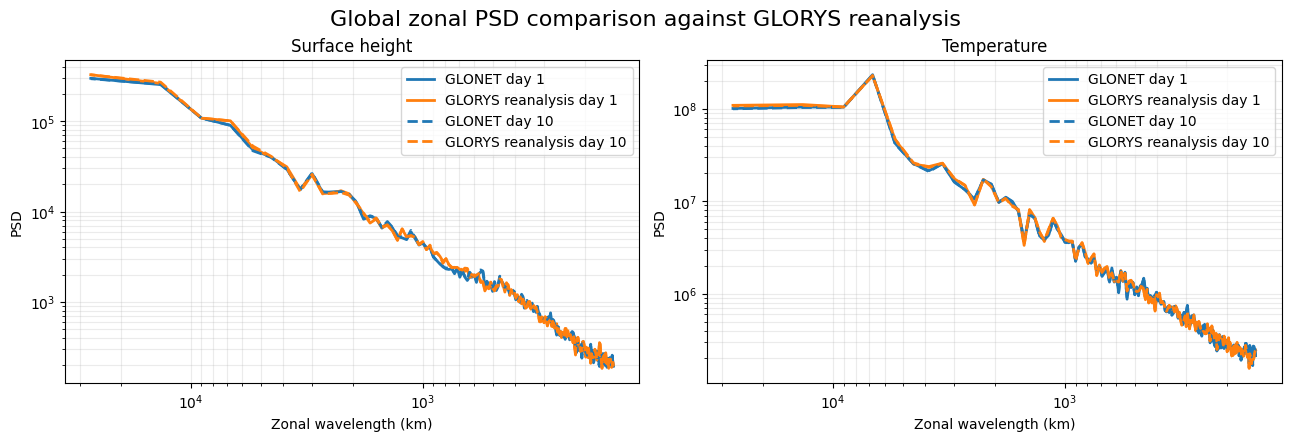

In [10]:
glorys_zonal_psd_figure = oceanbench.visualization.plot_zonal_longitude_psd_comparison_gallery(
    challenger_dataset,
    glorys_dataset,
    "GLORYS reanalysis",
    lead_day_indices=[0, 9],
)